In [39]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import pickle

Define the multilayer lattice with 4 sources

In [2]:
def multilayer_lattice_network(L=5, num_layers=2, source_positions=[(1, 1, 0), (3, 3, 0), (1, 3, 1), (3, 1, 1)]):
    G = nx.Graph()
    pos = {}

    for z in range(num_layers):
        for x in range(L):
            for y in range(L):
                node = z * L * L + x * L + y
                pos[node] = [x, y, z]

                # Source or sink
                if (x, y, z) in source_positions:
                    G.add_node(node, s=+1)
                else:
                    G.add_node(node, s=-1)

                # Intralayer edges
                if x > 0:
                    G.add_edge(node, z * L * L + (x - 1) * L + y)
                if y > 0:
                    G.add_edge(node, z * L * L + x * L + (y - 1))

                # Interlayer edges
                if z > 0:
                    G.add_edge(node, (z - 1) * L * L + x * L + y)

    return G, pos

Define the matrix of second moments

In [3]:
def compute_second_moment_matrix(G, beta, mu):
    """
    Compute the matrix M with entries M[i,j] = <S_i S_j>.

    Generators are nodes with G.nodes[u]['s'] > 0
    Consumers are nodes with G.nodes[u]['s'] <= 0
    """
    nodes = list(G.nodes)
    n = len(nodes)
    node_to_idx = {u: k for k, u in enumerate(nodes)}

    # Split nodes into generators and consumers
    idx_gen = [node_to_idx[u] for u in nodes if G.nodes[u]['s'] > 0]
    idx_con = [node_to_idx[u] for u in nodes if G.nodes[u]['s'] <= 0]

    Ng = len(idx_gen)
    Nc = len(idx_con)

    M = np.zeros((n, n), dtype=float)

    # Consumer-consumer: <S_i S_j> = mu^2
    for i in idx_con:
        for j in idx_con:
            M[i, j] = mu**2

    # Generator-consumer and consumer-generator:
    # <S_i S_j> = -(Nc/Ng) * mu^2
    gc_val = -(Nc / Ng) * mu**2
    for i in idx_gen:
        for j in idx_con:
            M[i, j] = gc_val
            M[j, i] = gc_val

    # Generator-generator
    offdiag_gg = (Nc**2 / Ng**2) * mu**2 - beta**2
    diag_gg = (Nc**2 / Ng**2) * mu**2 + (Ng - 1) * beta**2

    for i in idx_gen:
        for j in idx_gen:
            M[i, j] = offdiag_gg
        M[i, i] = diag_gg

    return M

Compute a local minimum from a given initial guess using Corson's method

In [4]:
def selfconsistent_minimum(E, k, MSM, gamma, cap_k=1, threshold=1e-10, max_repetitions=1000, verbose=False):
    
    # Normalize the capacities in the initial guess:        
    k = k * (cap_k / (np.sum(k**gamma))**(1/gamma))

    # Iterate until convergence:
    last_change = 1e5
    iterations = 0
    while last_change > threshold:

        # Compute the PTDF matrix via the Graph Laplacian:
        L = E @ np.diag(k) @ E.T                 
        PTDF = np.diag(k) @ E.T @ np.linalg.pinv(L)        

        # Compute the second moments of the flows
        F_sm = PTDF @ MSM @ PTDF.T
        F_squared = np.diag(F_sm)

        # Update the edge capacities a la Corson:
        k_old = k.copy()
        denom = (np.sum(F_squared**(gamma/(1+gamma))))**(1/gamma)
        k = F_squared**(1/(1+gamma))  / denom * cap_k

        # Compute the dissipation:
        D = 0
        for e in range(len(k)):
            if k[e] > 0:
                D += F_squared[e] / k[e]

        # change of edge capacities in this step. Used to check convergence.
        last_change = np.sum((k - k_old)**2)

        # Output to console in verbose mode:
        if verbose:
            print(f'Iteration {iterations}, Last Change {last_change:.4E}')

        # Put out a warning if the max number of iterations has been exceeded:
        iterations += 1
        if iterations > max_repetitions:
            print('Maximum number of repetitions reached!')
            break
        
        # Stop iteration when we reached a stationary point:
        if last_change < threshold:
            break

    return k, D


Plot the multilayer network in 3D

In [ ]:
def plot_multilayer_network_3d(G, pos, beta, gamma, label = None):

    # The maximum edge weight used for scaling
    edge_weights = [G[u][v].get("weight", 1.0) for u, v in G.edges()]
    max_weight = max(edge_weights) if edge_weights else 1.0

    # Avoid division by zero
    if max_weight == 0:
        max_weight = 1.0

    # Create the 3D figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the edges with scaled linewidth
    for u, v in G.edges():
        x = [pos[u][0], pos[v][0]]
        y = [pos[u][1], pos[v][1]]
        z = [pos[u][2], pos[v][2]]
        w = G[u][v].get("weight", 1.0)
        if w <= 1e-9:
            continue
        lw = np.floor(1 + 8 / max_weight * w)  # Scale linewidth
        color_value = 0.5 - 0.5 * w / max_weight
        color_value = max(0, min(1, color_value))  # Ensure color is in [0, 1]
        ax.plot(x, y, z, color=str(color_value), linewidth=lw)

    # Plot the nodes
    for u in G.nodes():
        x, y, z = pos[u]
        if G.nodes[u]["s"] > 0:
            ax.scatter(x, y, z, color="#1f77b4", marker="s", s=100, label='Source' if u == 0 else "")
        else:
            ax.scatter(x, y, z, color="#ff7f0e", marker="o", s=100, label='Sink' if u == 0 else "")

    # Add shaded areas for the layers
    # Get the unique z-coordinates for the layers
    z_layers = list(set([pos[u][2] for u in G.nodes()]))
    for z_layer in z_layers:
        x_min, x_max = min(pos[u][0] for u in G.nodes()), max(pos[u][0] for u in G.nodes())
        y_min, y_max = min(pos[u][1] for u in G.nodes()), max(pos[u][1] for u in G.nodes())
        x = np.linspace(x_min, x_max, 10)
        y = np.linspace(y_min, y_max, 10)
        X, Y = np.meshgrid(x, y)
        Z = np.full_like(X, z_layer)  # Create a plane at the z_layer
        ax.plot_surface(X, Y, Z, color='gray', alpha=0.2, zorder=-1, edgecolor = 'none', linewidth = 0)  # Add semi-transparent plane

    # Layout adjustments
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_axis_off()
    print(f'beta={beta}, gamma={gamma}')
    ax.set_position([0, 0, 1, 1])
    ax.margins(0)
    plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
    if label is not None:
        ax.text2D(0.05, 0.9, label, transform=ax.transAxes, fontsize=50, va="top", ha="left")
        fig.savefig(f"Fig10_{label}.pdf", bbox_inches="tight", pad_inches=0)
        plt.close(fig)
    else:
        plt.show()

Symmetry measures

In [ ]:
def partition_edges_by_layer(G, pos):
    """
    Partition edges into: intra_A, intra_B, inter based on z-coordinate in pos[node] = [x, y, z].
    """
    edge_list = list(G.edges())

    intra_A = []
    intra_B = []
    inter = []

    for e, (u, v) in enumerate(edge_list):
        zu = pos[u][2]
        zv = pos[v][2]

        if zu == 0 and zv == 0:
            intra_A.append(e)
        elif zu == 1 and zv == 1:
            intra_B.append(e)
        else:
            inter.append(e)

    return {"edge_list": edge_list, "intra_A": np.array(intra_A, dtype=int), "intra_B": np.array(intra_B, dtype=int),
            "inter": np.array(inter, dtype=int)}

def safe_sum(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(x)) if len(x) > 0 else 0.0

def safe_count_active(x, threshold=1e-8):
    x = np.asarray(x, dtype=float)
    return int(np.sum(x > threshold)) if len(x) > 0 else 0

def safe_cv(x, threshold=1e-12):
    """
    Coefficient of variation = std / mean.
    Returns np.nan if mean is too small.
    """
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    m = np.mean(x)
    if abs(m) < threshold:
        return np.nan
    return float(np.std(x) / m)

def compute_multiplex_metrics(G, pos, k, threshold_active=1e-8):
    """
    Compute symmetry and sparsity metrics for one capacity vector k.
    """
    parts = partition_edges_by_layer(G, pos)

    idx_A = parts["intra_A"]
    idx_B = parts["intra_B"]
    idx_I = parts["inter"]

    k = np.asarray(k, dtype=float)

    kA = k[idx_A]
    kB = k[idx_B]
    kI = k[idx_I]

    sum_A = safe_sum(kA)
    sum_B = safe_sum(kB)

    # normalized intralayer capacity imbalance
    denom_AB = sum_A + sum_B
    if denom_AB > 0:
        layer_imbalance = abs(sum_A - sum_B) / denom_AB
    else:
        layer_imbalance = np.nan

    # interlayer heterogeneity - but only over active links
    #inter_cv = safe_cv(kI)
    inter_cv = safe_cv(kI[kI > threshold_active])

    # active link counts
    n_total = safe_count_active(k, threshold_active)
    n_A = safe_count_active(kA, threshold_active)
    n_B = safe_count_active(kB, threshold_active)
    n_I = safe_count_active(kI, threshold_active)

    n_max = max(n_A, n_B)
    n_min = min(n_A, n_B)
    n_diff = abs(n_A - n_B)

    return {"layer_imbalance": layer_imbalance, "inter_cv": inter_cv, "n_active_total": n_total,
            "n_active_inter": n_I, "n_active_max": n_max, "n_active_min": n_min, "n_active_diff": n_diff}

def attach_metrics_to_results(results, G, pos, threshold_active=1e-8):
    """
    Compute multiplex metrics for every successful scan point.
    """
    for entry in results["grid"]:
        if entry["success"] and entry["k"] is not None:
            entry["metrics"] = compute_multiplex_metrics(G, pos, entry["k"], threshold_active=threshold_active)
        else:
            entry["metrics"] = None

    beta_values = np.array(results["beta_values"], dtype=float)
    gamma_values = np.array(results["gamma_values"], dtype=float)

    for entry in results["grid"]:
        ib = np.where(np.isclose(beta_values, entry["beta"]))[0][0]
        ig = np.where(np.isclose(gamma_values, entry["gamma"]))[0][0]
        results["table"][ib][ig] = entry

    return results

Plotting phase diagram

In [ ]:
def _extract_field_grid(results, field):
    beta_values = np.array(results["beta_values"], dtype=float)
    gamma_values = np.array(results["gamma_values"], dtype=float)

    nb = len(beta_values)
    ng = len(gamma_values)

    Z = np.full((nb, ng), np.nan)

    for entry in results["grid"]:
        beta = entry["beta"]
        gamma = entry["gamma"]

        ib = np.where(np.isclose(beta_values, beta))[0][0]
        ig = np.where(np.isclose(gamma_values, gamma))[0][0]

        if field == "n_active":
            Z[ib, ig] = entry["n_active"] if entry["success"] else np.nan
        elif field == "min_k":
            Z[ib, ig] = entry["min_k"] if entry["success"] else np.nan
        elif field == "D":
            Z[ib, ig] = entry["D"] if entry["success"] else np.nan
        else:
            metrics = entry.get("metrics", None)
            if entry["success"] and metrics is not None and field in metrics:
                Z[ib, ig] = metrics[field]

    return beta_values, gamma_values, Z

def plot_phase(results=None, filename=None, field="n_active_total", gamma_range=None, beta_range=None, title = None):
    """
    Plot a given metric from the following options:
    - Valid top-level fields: "n_active", "min_k", "D"
    - Valid metric fields (if metrics are attached): "layer_imbalance", "inter_cv", "n_active_total", "n_active_inter",
    "n_active_max", "n_active_min", "n_active_diff"

    For discrete fields (all n_active* fields), the colorbar is discrete and
    only shows values that actually occur in the data.
    """
    if results is None:
        if filename is None:
            raise ValueError("Provide either results or filename.")
        with open(filename, "rb") as f:
            results = pickle.load(f)

    beta_values, gamma_values, Z = _extract_field_grid(results, field)

    # Custom beta or gamma range
    if gamma_range is not None:
        gmin, gmax = gamma_range
        gamma_mask = (gamma_values >= gmin) & (gamma_values <= gmax)
    else:
        gamma_mask = np.ones_like(gamma_values, dtype=bool)

    if beta_range is not None:
        bmin, bmax = beta_range
        beta_mask = (beta_values >= bmin) & (beta_values <= bmax)
    else:
        beta_mask = np.ones_like(beta_values, dtype=bool)

    #Use reversed viridis so black hatching is visible
    cmap = 'viridis_r'

    # Flip x-direction so gamma increases left -> right
    Z_plot = Z[:, ::-1]
    gamma_plot = gamma_values[::-1]

    # Apply masks for custom beta/gamma range
    gamma_mask_plot = gamma_mask[::-1]

    Z_plot = Z_plot[beta_mask][:, gamma_mask_plot]
    beta_plot = beta_values[beta_mask]
    gamma_plot = gamma_plot[gamma_mask_plot]

    nb, ng = Z_plot.shape

    discrete_fields = {"n_active", "n_active_total", "n_active_inter", "n_active_max", "n_active_min", "n_active_diff"}

    fig, ax = plt.subplots(figsize=(12, 10))

    if field in discrete_fields:
        values = np.unique(Z_plot[np.isfinite(Z_plot)])
        values = np.sort(np.round(values).astype(int))

        if len(values) == 0:
            raise ValueError(f"No finite values found for field '{field}'.")

        nvals = len(values)
        base_cmap = plt.get_cmap(cmap, nvals)
        colors = base_cmap(np.arange(nvals))
        discrete_cmap = ListedColormap(colors)

        if nvals == 1:
            boundaries = [values[0] - 0.5, values[0] + 0.5]
            tick_positions = [values[0]]
        else:
            mid = (values[:-1] + values[1:]) / 2
            boundaries = np.concatenate(([values[0] - 0.5], mid, [values[-1] + 0.5]))
            tick_positions = (boundaries[:-1] + boundaries[1:]) / 2

        norm = BoundaryNorm(boundaries, discrete_cmap.N)

        im = ax.imshow(Z_plot, origin="lower", aspect="auto", cmap=discrete_cmap, norm=norm, interpolation="none")

        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.minorticks_off()
        cbar.set_ticks(tick_positions)
        cbar.set_ticklabels([str(v) for v in values])

        if field == 'n_active_max':
            # Build hatch field from the same results object
            _, _, Z_hatch = _extract_field_grid(results, "n_active_inter")
            Z_hatch = Z_hatch[:, ::-1]          # Flip gamma as for the base plot
            Z_hatch = Z_hatch[beta_mask][:, gamma_mask_plot]   # Custom ranges for beta and gamma

            # coordinates in image-index space
            x = np.arange(Z_plot.shape[1])
            y = np.arange(Z_plot.shape[0])
            X, Y = np.meshgrid(x, y)

            # hatch where n_active_inter == 5
            ax.contourf(X, Y, Z_hatch, levels=[4.5, 5.5], colors="none", hatches=["//"], alpha=0)

    else:
        im = ax.imshow(Z_plot, origin="lower", aspect="auto", cmap=cmap, interpolation="none")
        cbar = plt.colorbar(im, ax=ax)

    max_ticks_x=5
    max_ticks_y=5
    step_x = max(1, int(np.ceil(ng / max_ticks_x)))
    step_y = max(1, int(np.ceil(nb / max_ticks_y)))

    xticks = np.arange(0, ng, step_x)
    yticks = np.arange(0, nb, step_y)

    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{gamma_plot[i]:.2f}" for i in xticks])

    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{beta_plot[i]:.2f}" for i in yticks])

    ax.set_xlabel(r"$\gamma$", fontsize=35)
    ax.set_ylabel(r"$\beta$", fontsize=35)
    ax.tick_params(axis='both', labelsize=35) 
    cbar.ax.tick_params(labelsize=35)

    if title is None:
        ax.set_title(field, fontsize = 35)
    else:
        ax.set_title(title, fontsize = 35)

    plt.tight_layout()
    return fig, ax, gamma_plot, beta_plot

In [192]:
def random_tree_guess(G, edge_list):
    """
    Build an initial capacity vector on a random spanning tree.
    """
    num_edges = len(edge_list)
    T = nx.random_spanning_tree(G, weight=None)
    tree_edges = {frozenset((u, v)) for u, v in T.edges()}

    k_guess = np.zeros(num_edges, dtype=float)
    for e, (u, v) in enumerate(edge_list):
        if frozenset((u, v)) in tree_edges:
            k_guess[e] = 1.0 + 0.1 * np.random.rand()

    return k_guess

def solve_one_point(E, MSM, gamma, G, previous_k=None, cap_k=1, verbose=False):
    """
    Solve one parameter point using 4 seeds:
      1. continuation seed, if available
      2. all-ones
      3. random dense configuration
      4. random spanning tree configuration
    Returns best converged solution.
    """
    num_edges = E.shape[1]
    edge_list = list(G.edges())

    seeds = []

    if previous_k is not None:
        seeds.append(("previous", previous_k.copy()))

    seeds.append(("ones", np.ones(num_edges, dtype=float)))
    seeds.append(("random", 0.5 + np.random.rand(num_edges)))
    seeds.append(("tree", random_tree_guess(G, edge_list)))

    best = {"success": False, "k": None, "D": np.inf, "seed_name": None}

    all_solutions = []

    for seed_name, k_guess in seeds:
        try:
            k_sol, D_sol = selfconsistent_minimum(E, k_guess.copy(), MSM, gamma, cap_k=cap_k, verbose=False)

            success = np.all(np.isfinite(k_sol)) and np.isfinite(D_sol)
            if success:
                all_solutions.append({"seed_name": seed_name, "k": k_sol.copy(), "D": float(D_sol)})

                if D_sol < best["D"]:
                    best["success"] = True
                    best["k"] = k_sol.copy()
                    best["D"] = float(D_sol)
                    best["seed_name"] = seed_name

        except Exception as err:
            if verbose:
                print(f"seed {seed_name} failed: {err}")

    best["all_solutions"] = all_solutions
    return best

def scan_phase_diagram(G, gamma_values, beta_values, mu, cap_k=1, save_file="phase_scan.pkl", threshold_active=1e-8, verbose=True):
    """
    Coarse continuation scan with 4 seeds per point:
      - previous solution
      - all ones
      - random dense
      - random spanning tree
    """
    E = nx.incidence_matrix(G, oriented=True).toarray().astype(float)

    results = {"gamma_values": np.array(gamma_values, dtype=float), "beta_values": np.array(beta_values, dtype=float),
        "mu": float(mu), "cap_k": float(cap_k), "grid": [], "table": [[None for _ in gamma_values] for _ in beta_values]}

    total_points = len(beta_values) * len(gamma_values)
    point_counter = 0

    for ib, beta in enumerate(beta_values):
        MSM = compute_second_moment_matrix(G, beta, mu)
        previous_k = None

        for ig, gamma in enumerate(gamma_values):
            point_counter += 1

            if verbose:
                print(f"[{point_counter}/{total_points}]", end="\r", flush=True)

            sol = solve_one_point(E, MSM, gamma, G, previous_k=previous_k, cap_k=cap_k, verbose=False)

            if sol["success"]:
                previous_k = sol["k"].copy()
                k = sol["k"]
                D = sol["D"]
                min_k = float(np.min(k))
                n_active = int(np.sum(k > threshold_active))
            else:
                k = None
                D = np.inf
                min_k = np.nan
                n_active = 0

            entry = {"beta": float(beta), "gamma": float(gamma), "success": sol["success"], "D": D, "k": k, "min_k": min_k,
                     "n_active": n_active, "best_seed": sol["seed_name"], "all_solutions": sol["all_solutions"]}

            results["grid"].append(entry)
            results["table"][ib][ig] = entry

            with open(save_file, "wb") as f:
                pickle.dump(results, f)

    if verbose:
        print()

    return results

def get_scan_entry(results, beta, gamma, atol=1e-12):
    beta_values = np.array(results["beta_values"], dtype=float)
    gamma_values = np.array(results["gamma_values"], dtype=float)

    ib = np.where(np.isclose(beta_values, beta, atol=atol))[0]
    ig = np.where(np.isclose(gamma_values, gamma, atol=atol))[0]

    if len(ib) == 0 or len(ig) == 0:
        raise ValueError(f"Point (beta={beta}, gamma={gamma}) not found in scan.")

    return results["table"][ib[0]][ig[0]]

def graph_with_capacities(G, k, threshold=1e-9):
    """
    Return a copy of G where edges below threshold are removed and
    remaining edges carry attribute 'weight' = capacity.
    """
    Gres = G.copy()
    edge_list = list(G.edges())

    for e, (u, v) in enumerate(edge_list):
        if k[e] < threshold:
            if Gres.has_edge(u, v):
                Gres.remove_edge(u, v)
        else:
            Gres.edges[u, v]["weight"] = k[e]

    return Gres

def plot_scan_configuration(results, G, pos, beta, gamma, threshold=1e-9, label = None):
    """
    Plot the best stored configuration at a selected scan point.
    """
    entry = get_scan_entry(results, beta, gamma)

    if not entry["success"] or entry["k"] is None:
        print(f"No converged solution stored for beta={beta}, gamma={gamma}")
        return

    Gres = graph_with_capacities(G, entry["k"], threshold=threshold)

    print(f"beta={beta}, gamma={gamma}, D={entry['D']:.6g}, n_active={entry['n_active']}, best_seed={entry['best_seed']}")
    plot_multilayer_network_3d(Gres, pos, beta, gamma, label)

Refine scan by comparing to neighbors

In [9]:
def normalize_k(k, eps=1e-16):
    k = np.asarray(k, dtype=float)
    s = np.sum(k)
    if s < eps:
        return k.copy()
    return k / s


def k_distance(k1, k2):
    """
    L2 distance between normalized capacity vectors.
    """
    a = normalize_k(k1)
    b = normalize_k(k2)
    return np.linalg.norm(a - b)


def same_solution(k1, k2, tol=1e-6):
    return k_distance(k1, k2) < tol

def collect_neighbor_seeds(results, ib, ig):
    """
    Collect nearby stored best solutions from the scan table.
    """
    seeds = []
    table = results["table"]
    nb = len(table)
    ng = len(table[0])

    neighbor_offsets = [
        (0, 0),      # current point
        (0, -1),     # left
        (0, 1),      # right
        (-1, 0),     # below
        (1, 0),      # above
        (-1, -1),
        (-1, 1),
        (1, -1),
        (1, 1),
    ]

    for db, dg in neighbor_offsets:
        jb = ib + db
        jg = ig + dg
        if 0 <= jb < nb and 0 <= jg < ng:
            entry = table[jb][jg]
            if entry is not None and entry["success"] and entry["k"] is not None:
                seeds.append((f"saved_{jb}_{jg}", entry["k"].copy()))

    return seeds

def solve_one_point_from_saved(E, MSM, gamma, G, saved_seeds=None, cap_k=1, verbose=False):
    """
    Solve one point using:
      - saved nearby solutions
      - all-ones
      - one random dense
      - one random tree
    """
    num_edges = E.shape[1]
    edge_list = list(G.edges())

    seeds = []

    if saved_seeds is not None:
        seeds.extend(saved_seeds)

    seeds.append(("ones", np.ones(num_edges, dtype=float)))
    seeds.append(("random", 0.5 + np.random.rand(num_edges)))
    seeds.append(("tree", random_tree_guess(G, edge_list)))

    best = {"success": False, "k": None, "D": np.inf, "seed_name": None, "all_solutions": []}

    for seed_name, k_guess in seeds:
        try:
            k_sol, D_sol = selfconsistent_minimum(E, k_guess.copy(), MSM, gamma, cap_k=cap_k, verbose=False)

            success = np.all(np.isfinite(k_sol)) and np.isfinite(D_sol)
            if success:
                best["all_solutions"].append({"seed_name": seed_name, "k": k_sol.copy(), "D": float(D_sol)})

                if D_sol < best["D"]:
                    best["success"] = True
                    best["k"] = k_sol.copy()
                    best["D"] = float(D_sol)
                    best["seed_name"] = seed_name

        except Exception as err:
            if verbose:
                print(f"seed {seed_name} failed: {err}")

    return best


def refine_phase_scan_from_saved(G, results, save_file="phase_scan_refined.pkl", cap_k=1, threshold_active=1e-8,
                                 d_tol=1e-10, k_tol=1e-6, verbose=True):
    """
    Re-scan all points using saved neighboring solutions as seeds.
    Updates entries if a better or genuinely different solution is found.
    """
    E = nx.incidence_matrix(G, oriented=True).toarray().astype(float)

    beta_values = np.array(results["beta_values"], dtype=float)
    gamma_values = np.array(results["gamma_values"], dtype=float)
    mu = float(results["mu"])

    nb = len(beta_values)
    ng = len(gamma_values)
    total_points = nb * ng
    point_counter = 0

    if "refinement_log" not in results:
        results["refinement_log"] = []

    for ib in range(nb):
        beta = beta_values[ib]
        MSM = compute_second_moment_matrix(G, beta, mu)

        for ig in range(ng):
            gamma = gamma_values[ig]
            point_counter += 1

            if verbose:
                print(f"[{point_counter}/{total_points}]", end="\r", flush=True)

            old_entry = results["table"][ib][ig]
            saved_seeds = collect_neighbor_seeds(results, ib, ig)

            sol = solve_one_point_from_saved(E, MSM, gamma, G, saved_seeds=saved_seeds, cap_k=cap_k, verbose=False)

            if not sol["success"]:
                continue

            new_k = sol["k"]
            new_D = sol["D"]

            changed = False
            reason = None

            if old_entry is None or (not old_entry["success"]) or old_entry["k"] is None:
                changed = True
                reason = "new_success"
            else:
                old_k = old_entry["k"]
                old_D = old_entry["D"]

                if new_D < old_D - d_tol:
                    changed = True
                    reason = "better_D"
                elif abs(new_D - old_D) <= d_tol and not same_solution(new_k, old_k, tol=k_tol):
                    changed = True
                    reason = "different_branch_same_D"

            if changed:
                min_k = float(np.min(new_k))
                n_active = int(np.sum(new_k > threshold_active))

                entry = {"beta": float(beta), "gamma": float(gamma), "success": True, "D": float(new_D), "k": new_k.copy(),
                    "min_k": min_k, "n_active": n_active, "best_seed": sol["seed_name"], "all_solutions": sol["all_solutions"],
                    "updated_in_refinement": True, "update_reason": reason}

                results["table"][ib][ig] = entry

                # also update flat grid entry
                for idx, flat_entry in enumerate(results["grid"]):
                    if np.isclose(flat_entry["beta"], beta) and np.isclose(flat_entry["gamma"], gamma):
                        results["grid"][idx] = entry
                        break

                results["refinement_log"].append({"beta": float(beta), "gamma": float(gamma),
                    "reason": reason, "old_D": None if old_entry is None else old_entry["D"], "new_D": float(new_D)})

                with open(save_file, "wb") as f:
                    pickle.dump(results, f)

    if verbose:
        print()

    return results

We start with a coarse scan

[144/144]


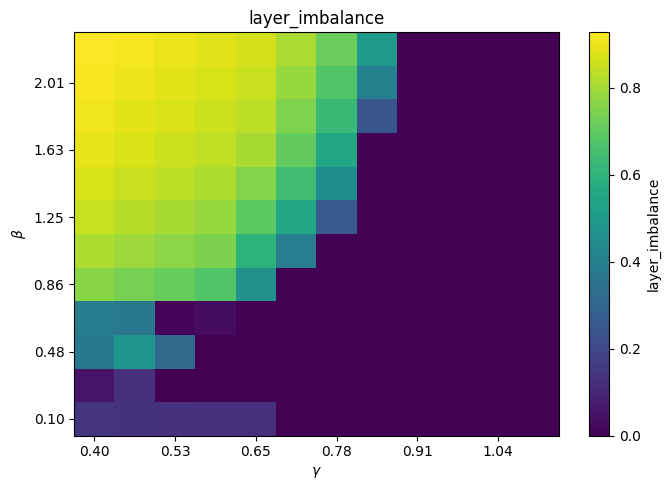

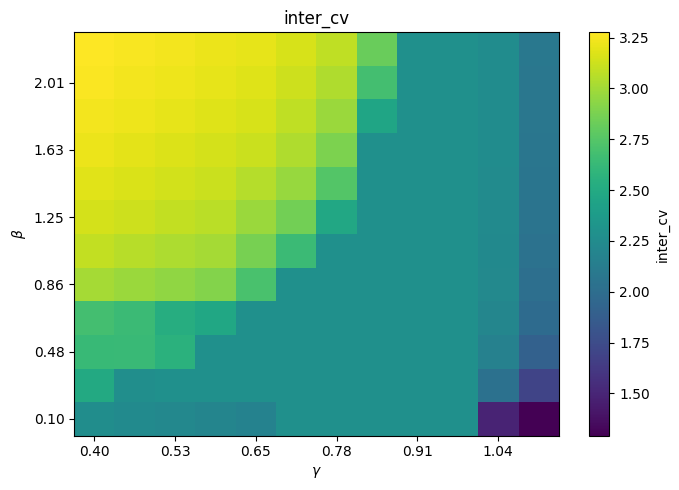

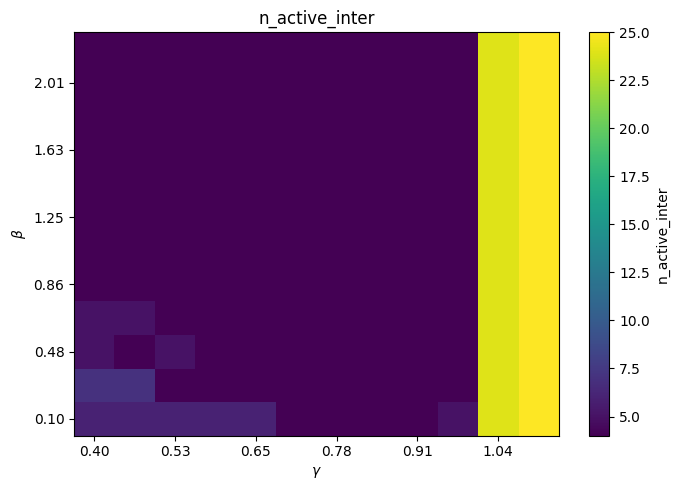

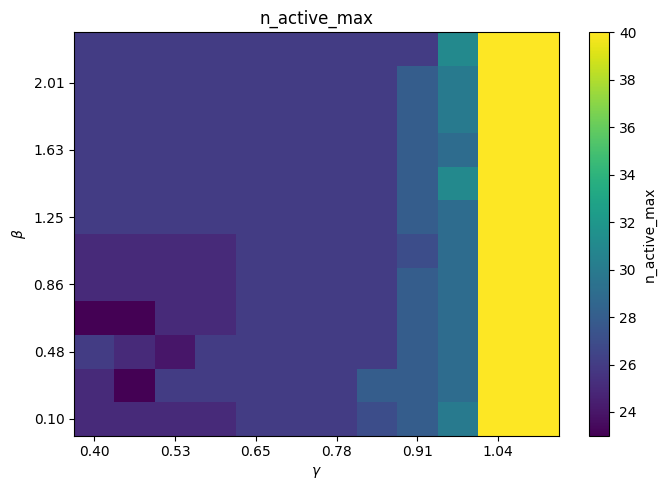

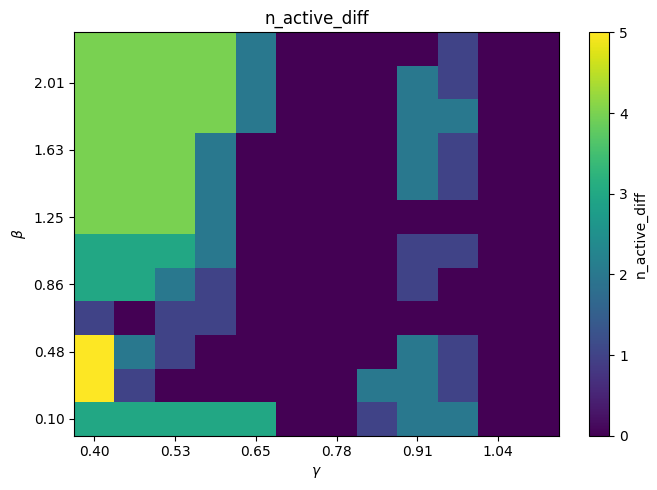

In [14]:
mu = 4/46 # such that Nc / Ng mu = 1

G, pos = multilayer_lattice_network()

beta_values = np.linspace(0.1, 2.2, 12)
gamma_values = np.linspace(1.1, 0.4, 12)

results_coarse = scan_phase_diagram(G, gamma_values=gamma_values, beta_values=beta_values, mu=mu, save_file="coarse_scan_final.pkl", verbose=True)

results_coarse_w_metrics = attach_metrics_to_results(results_coarse, G, pos)

plot_phase(results_coarse_w_metrics, field="layer_imbalance")
plot_phase(results_coarse_w_metrics, field="inter_cv")
plot_phase(results_coarse_w_metrics, field="n_active_inter")
plot_phase(results_coarse_w_metrics, field="n_active_max")
plot_phase(results_coarse_w_metrics, field="n_active_diff")

Then we refine results

In [15]:
results_refined = refine_phase_scan_from_saved(G, results_coarse, save_file="refined_coarse_scan_final.pkl", verbose=True)

results_refined = attach_metrics_to_results(results_refined, G, pos)

[144/144]


Plot refined results

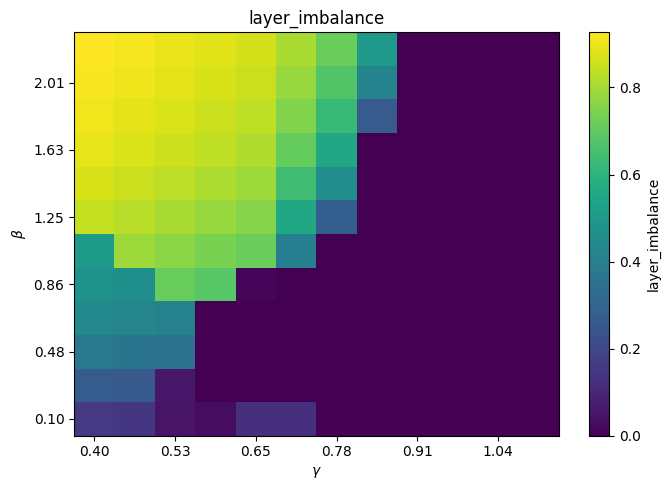

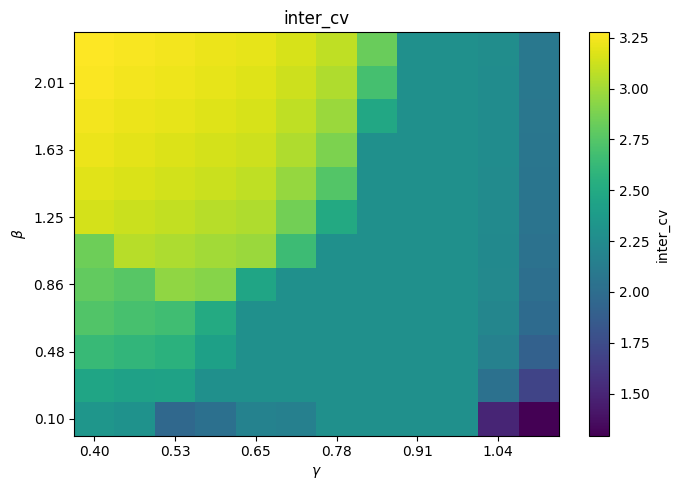

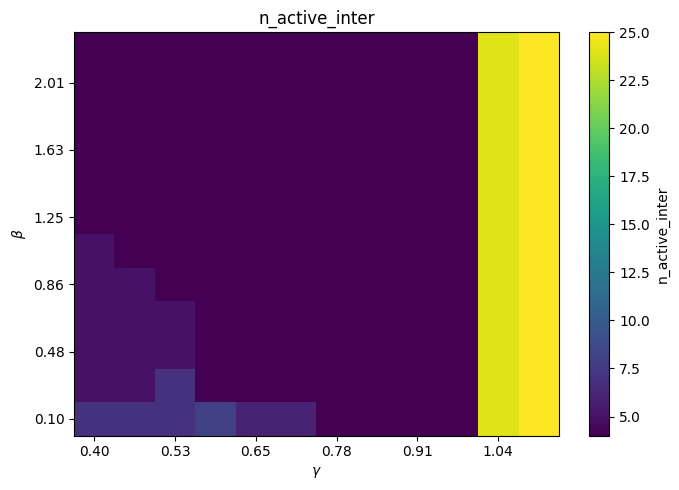

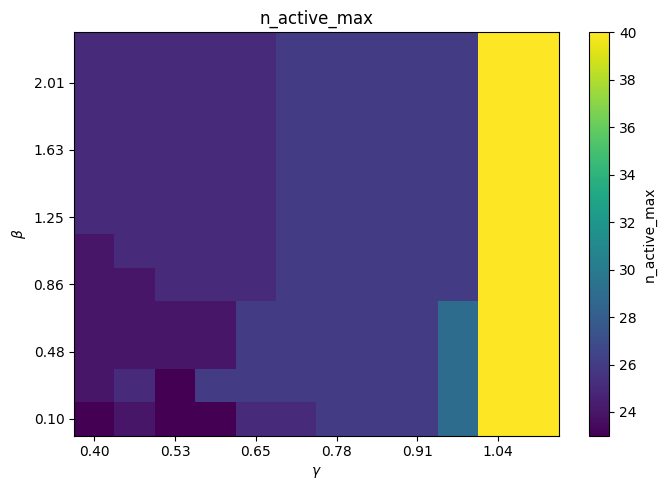

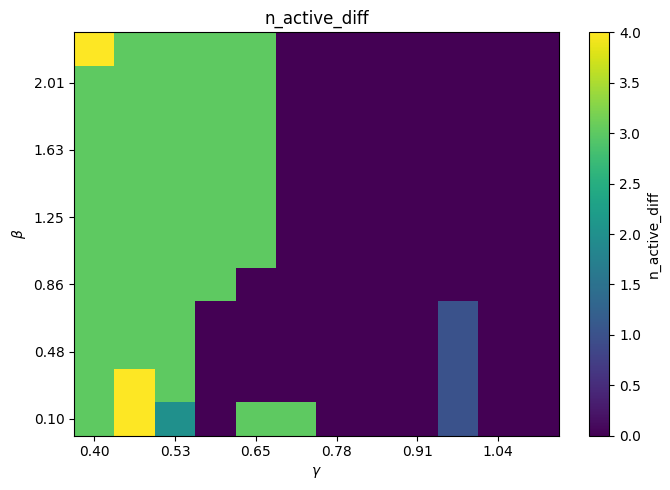

In [16]:
plot_phase(results_refined, field="layer_imbalance")
plot_phase(results_refined, field="inter_cv")
plot_phase(results_refined, field="n_active_inter")
plot_phase(results_refined, field="n_active_max")
plot_phase(results_refined, field="n_active_diff")

Now we perform a fine grained scan

In [ ]:
def build_unique_seed_bank(results_refined, uniqueness_tol=1e-5):
    """
    Build a bank of unique capacity vectors from a refined scan.
    Assumes input is results_refined.
    """
    seed_bank = []

    for entry in results_refined["grid"]:
        if not entry["success"] or entry["k"] is None:
            continue

        k = entry["k"]
        is_new = True

        for bank_entry in seed_bank:
            if same_solution(k, bank_entry["k"], tol=uniqueness_tol):
                is_new = False
                break

        if is_new:
            seed_bank.append({"id": len(seed_bank), "k": k.copy(), "beta": float(entry["beta"]), "gamma": float(entry["gamma"]),
                "D": float(entry["D"]), "n_active": int(entry["n_active"]), "best_seed": entry.get("best_seed", None)})

    return seed_bank

def summarize_seed_bank(seed_bank):
    print(f"Unique seeds: {len(seed_bank)}")
    for s in seed_bank:
        print(f"id={s['id']:3d}, beta={s['beta']:.3g}, gamma={s['gamma']:.3g}, D={s['D']:.6g}, n_active={s['n_active']}")


def get_nearest_saved_seed(results_refined, beta, gamma):
    """
    Return the best saved solution nearest in (beta, gamma) space.
    """
    best = None
    best_dist = np.inf

    for entry in results_refined["grid"]:
        if not entry["success"] or entry["k"] is None:
            continue

        db = beta - entry["beta"]
        dg = gamma - entry["gamma"]
        dist = db * db + dg * dg

        if dist < best_dist:
            best_dist = dist
            best = entry

    if best is None:
        return None

    return ("nearest_saved", best["k"].copy())

def get_closest_bank_seeds(seed_bank, beta, gamma, n_closest=3):
    """
    Return up to n_closest seeds from the unique bank, sorted by parameter distance.
    """
    scored = []

    for s in seed_bank:
        db = beta - s["beta"]
        dg = gamma - s["gamma"]
        dist = db * db + dg * dg
        scored.append((dist, s))

    scored.sort(key=lambda x: x[0])

    seeds = []
    for _, s in scored[:n_closest]:
        seeds.append((f"bank_{s['id']}", s["k"].copy()))

    return seeds

def solve_one_point_from_bank(E, MSM, gamma, G, beta, results_refined, seed_bank, previous_k=None, cap_k=1, n_bank_seeds=3, verbose=False):
    """
    Solve one point using a mixed seed set.
    """
    num_edges = E.shape[1]
    edge_list = list(G.edges())

    seeds = []

    if previous_k is not None:
        seeds.append(("previous", previous_k.copy()))

    nearest_saved = get_nearest_saved_seed(results_refined, beta, gamma)
    if nearest_saved is not None:
        seeds.append(nearest_saved)

    seeds.extend(get_closest_bank_seeds(seed_bank, beta, gamma, n_closest=n_bank_seeds))

    seeds.append(("ones", np.ones(num_edges, dtype=float)))
    seeds.append(("random", 0.5 + np.random.rand(num_edges)))
    seeds.append(("tree", random_tree_guess(G, edge_list)))

    # deduplicate seeds that are numerically identical
    unique_seeds = []
    for name, k_guess in seeds:
        duplicate = False
        for _, k_old in unique_seeds:
            if same_solution(k_guess, k_old, tol=1e-6):
                duplicate = True
                break
        if not duplicate:
            unique_seeds.append((name, k_guess))

    best = {"success": False, "k": None, "D": np.inf, "seed_name": None, "all_solutions": []}

    for seed_name, k_guess in unique_seeds:
        try:
            k_sol, D_sol = selfconsistent_minimum(E, k_guess.copy(), MSM, gamma, cap_k=cap_k, verbose=False)

            success = np.all(np.isfinite(k_sol)) and np.isfinite(D_sol)
            if success:
                best["all_solutions"].append({"seed_name": seed_name, "k": k_sol.copy(), "D": float(D_sol)})

                if D_sol < best["D"]:
                    best["success"] = True
                    best["k"] = k_sol.copy()
                    best["D"] = float(D_sol)
                    best["seed_name"] = seed_name

        except Exception as err:
            if verbose:
                print(f"seed {seed_name} failed: {err}")

    return best

def fine_scan_from_seed_bank(G, beta_values, gamma_values, mu, results_refined, seed_bank, cap_k=1, n_bank_seeds=3, threshold_active=1e-8,
                             uniqueness_tol=1e-5, save_file="fine_scan.pkl", verbose=True, grow_bank=True):
    """
    Fine scan using:
      - local continuation
      - nearest saved refined solution
      - nearest unique bank seeds
      - ones, random, tree

    If grow_bank=True, newly found distinct solutions are added to the bank.
    """
    E = nx.incidence_matrix(G, oriented=True).toarray().astype(float)

    results_fine = {"beta_values": np.array(beta_values, dtype=float), "gamma_values": np.array(gamma_values, dtype=float),
                    "mu": float(mu), "cap_k": float(cap_k), "grid": [], "table": [[None for _ in gamma_values] for _ in beta_values],
        "source_results_refined": results_refined}

    total_points = len(beta_values) * len(gamma_values)
    point_counter = 0

    for ib, beta in enumerate(beta_values):
        MSM = compute_second_moment_matrix(G, beta, mu)
        previous_k = None

        for ig, gamma in enumerate(gamma_values):
            point_counter += 1
            if verbose:
                print(f"[{point_counter}/{total_points}]", end="\r", flush=True)

            sol = solve_one_point_from_bank(E, MSM, gamma, G, beta=beta, results_refined=results_refined, seed_bank=seed_bank,
                                            previous_k=previous_k, cap_k=cap_k, n_bank_seeds=n_bank_seeds, verbose=False)

            if sol["success"]:
                previous_k = sol["k"].copy()
                k = sol["k"]
                D = sol["D"]
                min_k = float(np.min(k))
                n_active = int(np.sum(k > threshold_active))

                # check whether best solution is already represented in bank
                matched_bank_id = None
                for s in seed_bank:
                    if same_solution(k, s["k"], tol=uniqueness_tol):
                        matched_bank_id = s["id"]
                        break

                is_new_branch = matched_bank_id is None

                if is_new_branch and grow_bank:
                    new_entry = {"id": len(seed_bank), "k": k.copy(), "beta": float(beta), "gamma": float(gamma), "D": float(D),
                        "n_active": int(n_active), "best_seed": sol["seed_name"]}
                    seed_bank.append(new_entry)
                    matched_bank_id = new_entry["id"]

            else:
                k = None
                D = np.inf
                min_k = np.nan
                n_active = 0
                matched_bank_id = None
                is_new_branch = False

            entry = {"beta": float(beta), "gamma": float(gamma), "success": sol["success"], "D": float(D), "k": k, "min_k": min_k,
                     "n_active": n_active, "best_seed": sol["seed_name"], "matched_bank_id": matched_bank_id, "is_new_branch": is_new_branch,
                     "all_solutions": sol["all_solutions"]}

            results_fine["grid"].append(entry)
            results_fine["table"][ib][ig] = entry

            with open(save_file, "wb") as f:
                pickle.dump(results_fine, f)

    if verbose:
        print()

    return results_fine, seed_bank

In [24]:
seed_bank = build_unique_seed_bank(results_refined, uniqueness_tol=4e-2)
summarize_seed_bank(seed_bank)

Unique seeds: 24
id=  0, beta=0.1, gamma=1.1, D=34.6621, n_active=105
id=  1, beta=0.1, gamma=0.973, D=56.3936, n_active=61
id=  2, beta=0.1, gamma=0.909, D=74.4057, n_active=56
id=  3, beta=0.1, gamma=0.845, D=102.438, n_active=56
id=  4, beta=0.1, gamma=0.718, D=230.303, n_active=53
id=  5, beta=0.1, gamma=0.591, D=733.345, n_active=54
id=  6, beta=0.1, gamma=0.527, D=1613.61, n_active=51
id=  7, beta=0.1, gamma=0.464, D=4381.32, n_active=51
id=  8, beta=0.291, gamma=1.1, D=50.9138, n_active=105
id=  9, beta=0.291, gamma=0.909, D=109.056, n_active=56
id= 10, beta=0.291, gamma=0.527, D=2429.44, n_active=50
id= 11, beta=0.291, gamma=0.464, D=6467.91, n_active=51
id= 12, beta=0.482, gamma=0.973, D=121.849, n_active=61
id= 13, beta=0.482, gamma=0.591, D=1580.45, n_active=52
id= 14, beta=0.482, gamma=0.527, D=3401.34, n_active=50
id= 15, beta=0.673, gamma=0.782, D=449.494, n_active=56
id= 16, beta=0.673, gamma=0.4, D=43028.9, n_active=50
id= 17, beta=0.864, gamma=0.655, D=1543.57, n_activ

In [25]:
beta_values_fine = np.linspace(0.1, 2.2, 120)
gamma_values_fine = np.linspace(1.1, 0.4, 120)

results_fine, seed_bank = fine_scan_from_seed_bank(G, beta_values=beta_values_fine, gamma_values=gamma_values_fine,
    mu=results_refined["mu"], results_refined=results_refined, seed_bank=seed_bank, cap_k=1, n_bank_seeds=23, threshold_active=1e-8,
    uniqueness_tol=1e-3, save_file="fine_results_final_120x120.pkl", verbose=True, grow_bank=True)

Maximum number of repetitions reached!


C:\Users\i.bacic\AppData\Local\Temp\ipykernel_37628\2801166246.py:21: RuntimeWarning: invalid value encountered in power
  denom = (np.sum(F_squared**(gamma/(1+gamma))))**(1/gamma)
C:\Users\i.bacic\AppData\Local\Temp\ipykernel_37628\2801166246.py:22: RuntimeWarning: invalid value encountered in power
  k = F_squared**(1/(1+gamma))  / denom * cap_k


Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetit

In [200]:
results_fine_w_metrics = attach_metrics_to_results(results_fine, G, pos)

In [149]:
def add_phase_label(ax, gamma, beta, text, gamma_plot, beta_plot, color="white", fontsize=12):
    ix = np.argmin(np.abs(gamma_plot - gamma))
    iy = np.argmin(np.abs(beta_plot - beta))
    ax.text(ix, iy, text, color=color, fontsize=fontsize, ha="center", va="center", fontweight="bold")

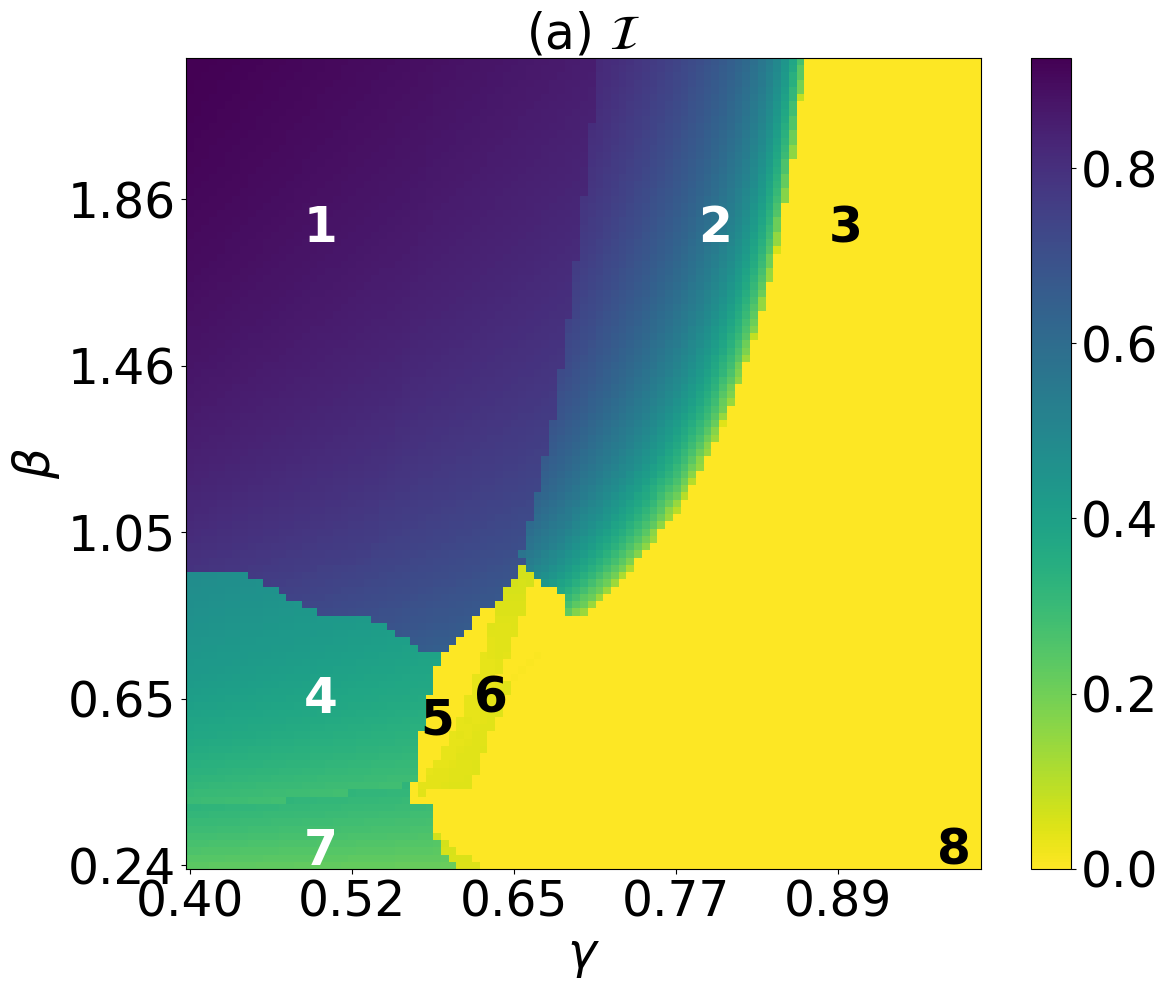

In [284]:
fig, ax, gamma_plot, beta_plot = plot_phase(results_fine_w_metrics, beta_range = (0.24, 2.2), gamma_range=(0.4, 1.0), field="layer_imbalance", title = r"(a) $\mathcal{I}$")

add_phase_label(ax, gamma=0.5, beta=1.8, text="1", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35)
add_phase_label(ax, gamma=0.8, beta=1.8, text="2", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35)
add_phase_label(ax, gamma=0.9, beta=1.8, text="3", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.5, beta=0.65, text="4", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35)
add_phase_label(ax, gamma=0.59, beta=0.6, text="5", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.63, beta=0.65, text="6", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.5, beta=0.28, text="7", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35)
add_phase_label(ax, gamma=0.98, beta=0.28, text="8", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
fig.savefig("Fig10a.pdf", bbox_inches="tight")

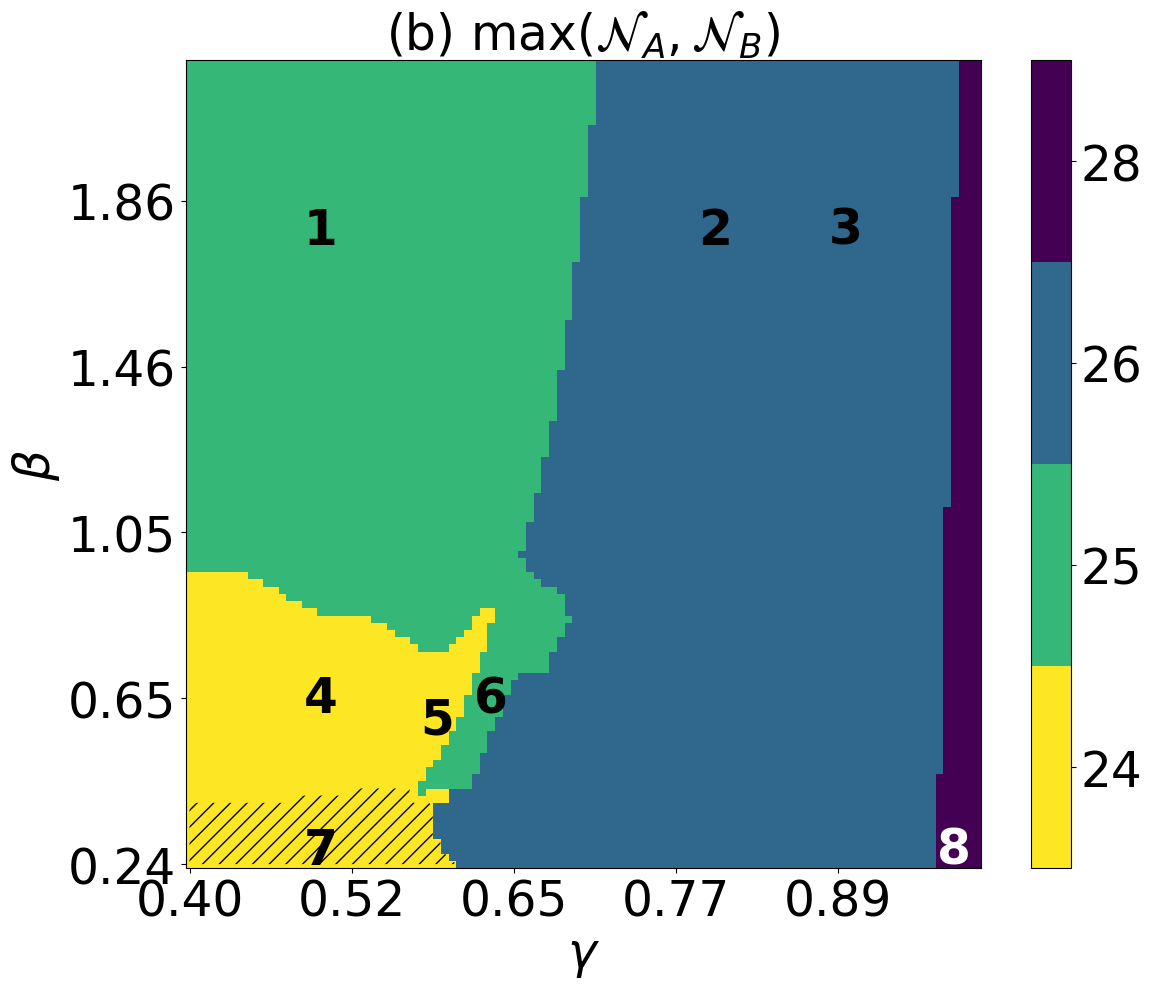

In [285]:
fig, ax, gamma_plot, beta_plot = plot_phase(results_fine_w_metrics, beta_range = (0.24, 2.2),gamma_range=(0.4, 1.0), field="n_active_max", title = r"(b) $\max (\mathcal{N}_A,\mathcal{N}_B)$")
add_phase_label(ax, gamma=0.5, beta=1.8, text="1", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.8, beta=1.8, text="2", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.9, beta=1.8, text="3", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.5, beta=0.65, text="4", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.59, beta=0.6, text="5", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.63, beta=0.65, text="6", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.5, beta=0.28, text="7", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.98, beta=0.28, text="8", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35)
fig.savefig("Fig10b.pdf", bbox_inches="tight")

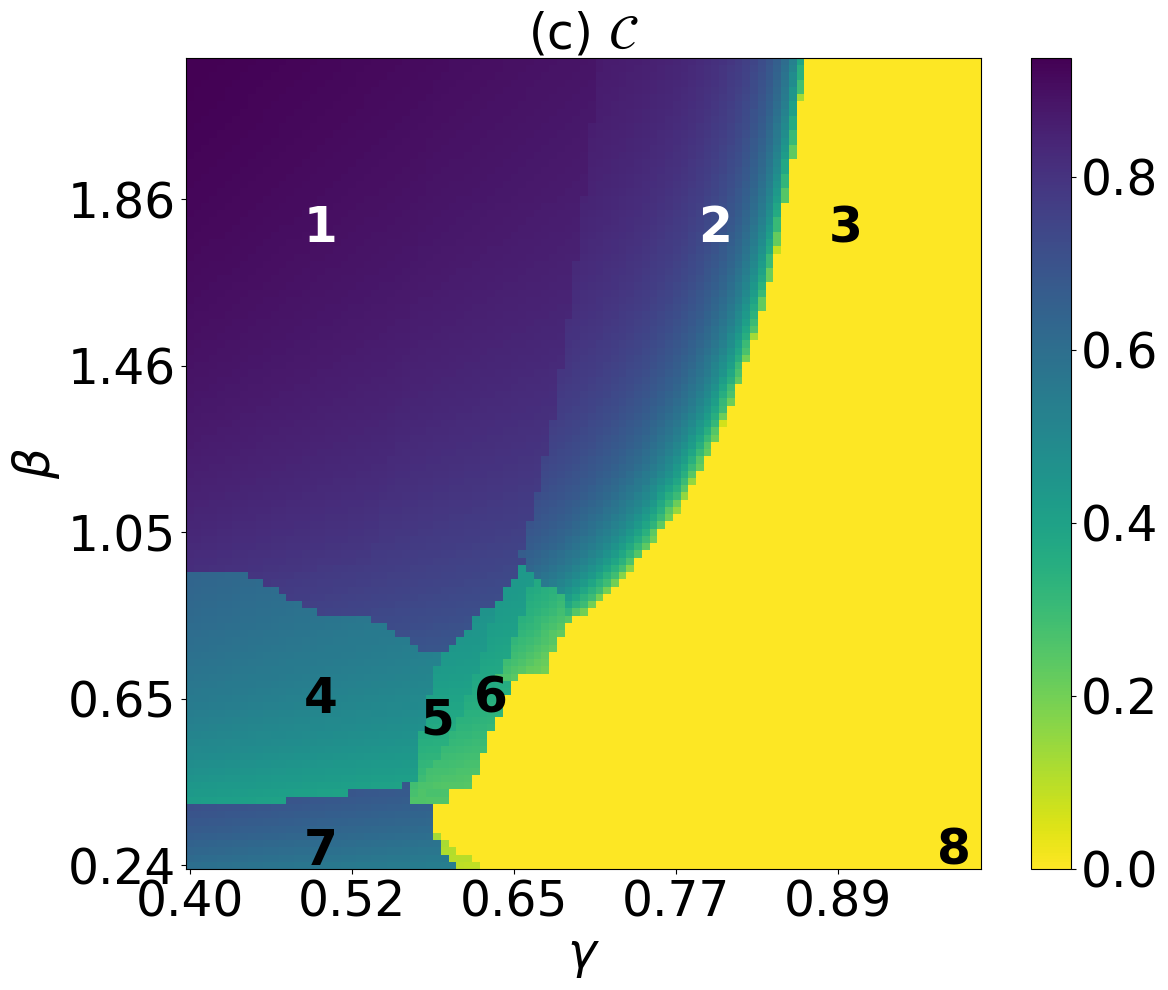

In [286]:
fig, ax, gamma_plot, beta_plot = plot_phase(results_fine_w_metrics, beta_range = (0.24, 2.2), gamma_range=(0.4, 1.0), field="inter_cv", title = r"(c) $\mathcal{C}$")
add_phase_label(ax, gamma=0.5, beta=1.8, text="1", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "white")
add_phase_label(ax, gamma=0.8, beta=1.8, text="2", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "white")
add_phase_label(ax, gamma=0.9, beta=1.8, text="3", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.5, beta=0.65, text="4", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.59, beta=0.6, text="5", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.63, beta=0.65, text="6", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.5, beta=0.28, text="7", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
add_phase_label(ax, gamma=0.98, beta=0.28, text="8", gamma_plot=gamma_plot, beta_plot=beta_plot, fontsize=35, color = "black")
fig.savefig("Fig10c_onlyactive.pdf", bbox_inches="tight")

Plot selected configurations:

gamma=0.5, beta=1.8, 1

gamma=0.8, beta=1.8, 2

gamma=0.9, beta=1.8, 3

gamma=0.5, beta=0.65, 4

gamma=0.59, beta=0.6, 5

gamma=0.63, beta=0.65, 6

gamma=0.66, beta=0.8, 7

gamma=0.5, beta=0.28, 8

gamma=0.98, beta=0.28, 9

1

In [198]:
plot_scan_configuration(results_fine, G, pos, beta=beta_values_fine[96], gamma=gamma_values_fine[102], label = 1)

beta=1.7941176470588236, gamma=0.5, D=19492.3, n_active=50, best_seed=previous
beta=1.7941176470588236, gamma=0.5


2

In [209]:
plot_scan_configuration(results_fine, G, pos, beta=beta_values_fine[96], gamma=gamma_values_fine[51], label = 2)

beta=1.7941176470588236, gamma=0.8, D=1565.97, n_active=56, best_seed=bank_4578
beta=1.7941176470588236, gamma=0.8


3

In [215]:
plot_scan_configuration(results_fine, G, pos, beta=beta_values_fine[96], gamma=gamma_values_fine[34], label = 3)

beta=1.7941176470588236, gamma=0.9, D=963.933, n_active=56, best_seed=bank_4570
beta=1.7941176470588236, gamma=0.9


4

In [249]:
plot_scan_configuration(results_fine, G, pos, beta=beta_values_fine[31], gamma=gamma_values_fine[102], label = 4)

beta=0.6470588235294117, gamma=0.5, D=6435.4, n_active=50, best_seed=previous
beta=0.6470588235294117, gamma=0.5


5

In [250]:
plot_scan_configuration(results_fine, G, pos, beta=beta_values_fine[29], gamma=gamma_values_fine[87], label = 5)

beta=0.6117647058823529, gamma=0.5882352941176471, D=2020.35, n_active=52, best_seed=previous
beta=0.6117647058823529, gamma=0.5882352941176471


6

In [251]:
plot_scan_configuration(results_fine, G, pos, beta=beta_values_fine[31], gamma=gamma_values_fine[80], label = 6)

beta=0.6470588235294117, gamma=0.6294117647058823, D=1406.93, n_active=53, best_seed=bank_1929
beta=0.6470588235294117, gamma=0.6294117647058823


7

In [287]:
plot_scan_configuration(results_fine, G, pos, beta=beta_values_fine[11], gamma=gamma_values_fine[102], label = 7)

beta=0.29411764705882354, gamma=0.5, D=3573.09, n_active=50, best_seed=previous
beta=0.29411764705882354, gamma=0.5


8

In [288]:
plot_scan_configuration(results_fine, G, pos, beta=beta_values_fine[11], gamma=gamma_values_fine[20], label = 8)

beta=0.29411764705882354, gamma=0.9823529411764707, D=79.8556, n_active=60, best_seed=previous
beta=0.29411764705882354, gamma=0.9823529411764707
